In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

In [85]:
df_world = pd.read_excel('solargis_pvpotential_countryranking_2020_data.xlsx', sheet_name= 'Country indicators',header=1, )

In [86]:
df_world.head(5)

,ISO_A3,Country or region,Note,World Bank \nRegion,"Total population, 2018","Total area, 2018",Evaluated area,Level 1 area \n(% of evaluated area),"Human development \nIndex, 2017","Gross domestic product (USD per capita), 2018",...,"Average practical potential \n(PVOUT Level 1, \nkWh/kWp/day), long-term","Average economic potential (LCOE, USD/kWh), 2018","Average PV \nseasonality index, long-term","PV equivalent area (% of total area), long-term","Cummulative installed PV capacity (MWp), 2018","Cummulative installed PV capacity (Wp per capita), 2018","Access to electricity\n(% of rural population), 2016","Electric power consumption (kWh per capita), 2014","Reliability of supply and transparency of tariff index, 2019","Approximate electricity \nTariffs for SMEs \n(US cent/kWh), 2019"
0,ABW,Aruba (Neth.),NaN,Other,105845,180.0,180,0.847926,NaN,25630.266492,...,4.9646,0.0853,1.1803,NaN,6.1,57.631442,92.452844,NaN,NaN,NaN
1,AFG,Afghanistan,NaN,SOA,37172386,652860.0,652860,0.587350,0.497695,520.896603,...,5.0159,0.0851,1.6665,NaN,22.0,0.591837,78.961074,NaN,0.0,17.6
2,AGO,Angola,NaN,AFR,30809762,1246700.0,1246700,0.751833,0.581179,3432.385736,...,4.6586,0.0919,1.3211,0.003,13.4,0.434927,15.984209,312.228825,3.0,4.6
3,ALB,Albania,NaN,ECA,2866376,27400.0,27400,0.614858,0.784911,5253.630064,...,4.0426,0.1051,2.3266,0.210,1.0,0.348873,100.000000,2309.366503,3.0,8.7
4,AND,Andorra,NaN,Other,77006,470.0,470,0.110961,0.857684,42029.762737,...,4.1990,0.0986,2.1531,NaN,0.0,0.000000,100.000000,NaN,NaN,NaN


### data cleanup and preprocessing

In [87]:
df_world.columns = (
    df_world.columns.str.strip()
        .str.lower()
        .str.replace("(", "_", regex=False)       # ✅ replace ( with _
        .str.replace(")", "", regex=False)        # remove )
        .str.replace(",", "", regex=False)        # clean commas
        .str.replace(r"\s+", "_", regex=True)     # spaces → _
)

print(df_world.columns.tolist())

['iso_a3', 'country_or_region', 'note', 'world_bank_region', 'total_population_2018', 'total_area_2018', 'evaluated_area', 'level_1_area__%_of_evaluated_area', 'human_development_index_2017', 'gross_domestic_product__usd_per_capita_2018', 'average_theoretical_potential__ghi_kwh/m2/day_long-term', 'average_practical_potential__pvout_level_1_kwh/kwp/day_long-term', 'average_economic_potential__lcoe_usd/kwh_2018', 'average_pv_seasonality_index_long-term', 'pv_equivalent_area__%_of_total_area_long-term', 'cummulative_installed_pv_capacity__mwp_2018', 'cummulative_installed_pv_capacity__wp_per_capita_2018', 'access_to_electricity__%_of_rural_population_2016', 'electric_power_consumption__kwh_per_capita_2014', 'reliability_of_supply_and_transparency_of_tariff_index_2019', 'approximate_electricity_tariffs_for_smes__us_cent/kwh_2019']


In [88]:
rename_map = {
    "country_or_region": "country",
    "world_bank_region": "region",
    "total_population_2018": "population",
    "total_area_2018": "total_area",
    "human_development_index_2017": "hdi",
    "gross_domestic_product__usd_per_capita_2018": "gdp_per_capita",
    "average_theoretical_potential__ghi_kwh/m2/day_long-term": "potential_ghi",
    "average_practical_potential__pvout_level_1_kwh/kwp/day_long-term": "potential_pvout",
    "average_economic_potential__lcoe_usd/kwh_2018": "potential_lcoe",
    "average_pv_seasonality_index_long-term": "seasonality",
    "pv_equivalent_area__%_of_total_area_long-term": "pv_equiv_area_pct",
    "cummulative_installed_pv_capacity__mwp_2018": "pv_capacity_mw",
    "cummulative_installed_pv_capacity__wp_per_capita_2018": "pv_wp_per_capita",
    "access_to_electricity__%_of_rural_population_2016": "rural_electricity_access",
    "electric_power_consumption__kwh_per_capita_2014": "power_consumption_per_capita",
    "reliability_of_supply_and_transparency_of_tariff_index_2019": "grid_reliability",
    "approximate_electricity_tariffs_for_smes__us_cent/kwh_2019":"electricity_tariffs"
}

df_world = df_world.rename(columns={k: v for k, v in rename_map.items() if k in df_world.columns})
print(df_world.columns.tolist())

['iso_a3', 'country', 'note', 'region', 'population', 'total_area', 'evaluated_area', 'level_1_area__%_of_evaluated_area', 'hdi', 'gdp_per_capita', 'potential_ghi', 'potential_pvout', 'potential_lcoe', 'seasonality', 'pv_equiv_area_pct', 'pv_capacity_mw', 'pv_wp_per_capita', 'rural_electricity_access', 'power_consumption_per_capita', 'grid_reliability', 'electricity_tariffs']


In [89]:

for col in df_world.columns:
    if col not in ["country", "region"]:
        df_world[col] = pd.to_numeric(df_world[col], errors="coerce")

print(df_world.isnull().sum())

iso_a3                               209
country                                0
note                                 209
region                                 0
population                             0
total_area                             2
evaluated_area                         0
level_1_area__%_of_evaluated_area      0
hdi                                   24
gdp_per_capita                         9
potential_ghi                          0
potential_pvout                        0
potential_lcoe                         0
seasonality                            0
pv_equiv_area_pct                     74
pv_capacity_mw                         6
pv_wp_per_capita                       6
rural_electricity_access              11
power_consumption_per_capita          72
grid_reliability                      26
electricity_tariffs                   27
dtype: int64


####Photovoltaic power output of a PV system (specific yield); in this case, the longterm power ouput produced by a utility-scale installation of monofacial modules fixed mounted at an optimum tilt, measured in kWh/kWp/day - pv_wp_per_capita. This can be considered as the solar adoption potential

In [90]:
#Outcome Variable

#Photovoltaic power capacity of a PV system; measured in kWh/kWp/day; per capita

df_world = df_world[df_world["pv_wp_per_capita"].notna()].copy()


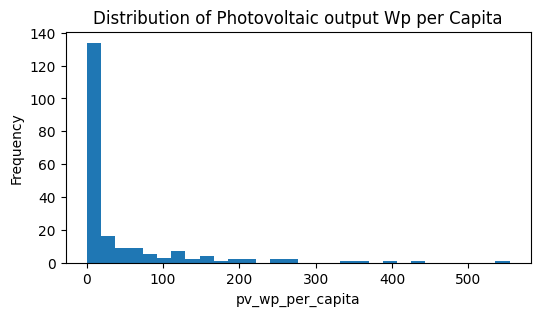

In [91]:
#Check if pv_wp_per_capita is skewed
plt.figure(figsize=(6, 3))

plt.hist(df_world['pv_wp_per_capita'], bins=30)
plt.title('Distribution of Photovoltaic output Wp per Capita')
plt.xlabel('pv_wp_per_capita')
plt.ylabel('Frequency')
plt.show()

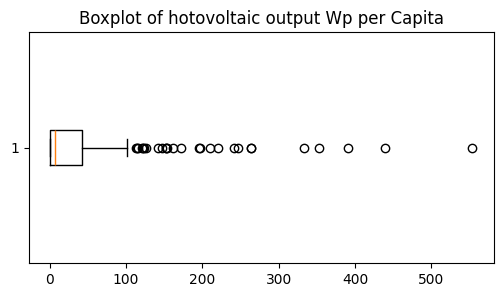

In [92]:
plt.figure(figsize=(6, 3))

plt.boxplot(df_world['pv_wp_per_capita'], vert=False)
plt.title('Boxplot of hotovoltaic output Wp per Capita')
plt.show()

The distribution of pv wp per capita is highly right-skewed, indicating that solar adoption is concentrated in a small number of countries, while the majority of countries have very low adoption levels.

In [93]:
df_world['pv_wp_per_capita'].skew()

np.float64(3.2090339059691013)

In [94]:
df_world['pv_wp_per_capita'].describe()

,pv_wp_per_capita
count,203.000000
mean,41.732078
std,82.244045
min,0.000000
25%,0.661693
50%,6.580547
75%,42.814107
max,553.854467


In [95]:
#as it is skewed , we will use log transformation
df_world["log_pv_wp_per_capita"] = np.log1p(df_world["pv_wp_per_capita"])

####Correlation between the identified outcome variable and other variables (chosen based on definitions)

In [96]:
#correlation analysis
corr_cols = [
    "log_pv_wp_per_capita",
    "gdp_per_capita",
    "potential_ghi",
    "potential_pvout",
    "potential_lcoe",
    "seasonality",
    "rural_electricity_access",
    "power_consumption_per_capita",
    "grid_reliability"
]

corr_cols = [c for c in corr_cols if c in df_world.columns]
corr = df_world[corr_cols].corr()

print(corr["log_pv_wp_per_capita"].sort_values(ascending=False))

log_pv_wp_per_capita            1.000000
grid_reliability                0.555192
rural_electricity_access        0.517860
power_consumption_per_capita    0.442011
gdp_per_capita                  0.382778
seasonality                     0.189074
potential_lcoe                  0.036133
potential_pvout                -0.178542
potential_ghi                  -0.259084
Name: log_pv_wp_per_capita, dtype: float64


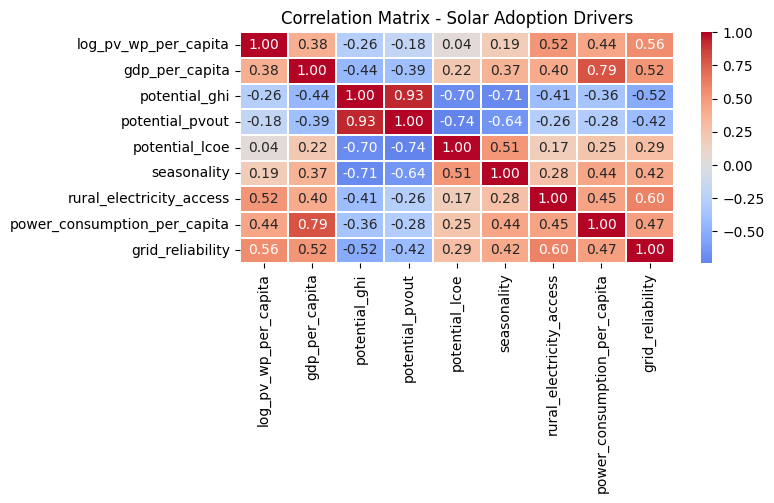

In [97]:
plt.figure(figsize=(7, 3))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Matrix - Solar Adoption Drivers")
plt.show()

Graphs defining key relationships

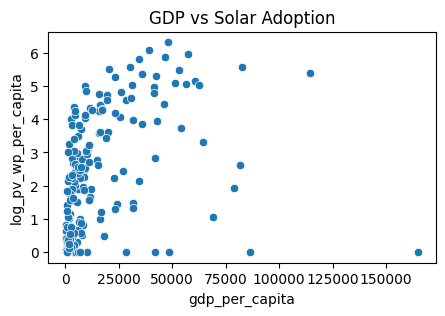

In [98]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    data=df_world,
    x='gdp_per_capita',
    y='log_pv_wp_per_capita'
)

plt.title("GDP vs Solar Adoption")
plt.show()

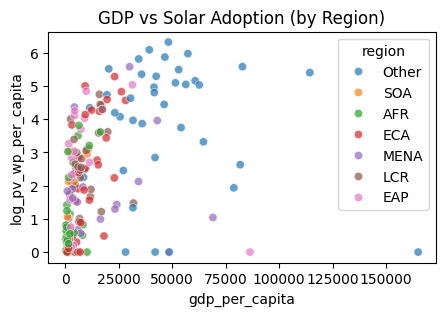

In [99]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    data=df_world,
    x="gdp_per_capita",
    y="log_pv_wp_per_capita",
    hue="region",
    alpha=0.7
)

plt.title("GDP vs Solar Adoption (by Region)")
plt.show()

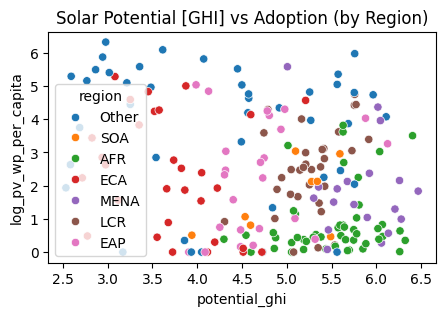

In [100]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    data=df_world,
    x='potential_ghi',
    y='log_pv_wp_per_capita',
    hue="region",
)

plt.title("Solar Potential [GHI] vs Adoption (by Region)")
plt.show()

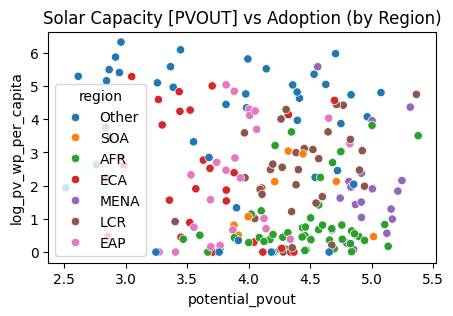

In [101]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    data=df_world,
    x='potential_pvout',
    y='log_pv_wp_per_capita',
    hue="region",
)

plt.title("Solar Capacity [PVOUT] vs Adoption (by Region)")
plt.show()

Text(0.5, 1.0, 'GDP vs Solar Adoption')

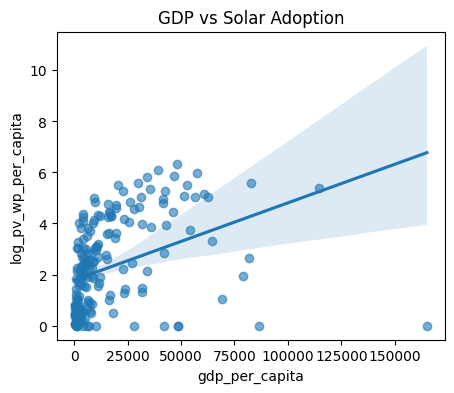

In [102]:
plt.figure(figsize=(5,4))
sns.regplot(
    data=df_world,
    x='gdp_per_capita',
    y='log_pv_wp_per_capita',
    scatter_kws={'alpha':0.6}
)
plt.title("GDP vs Solar Adoption")

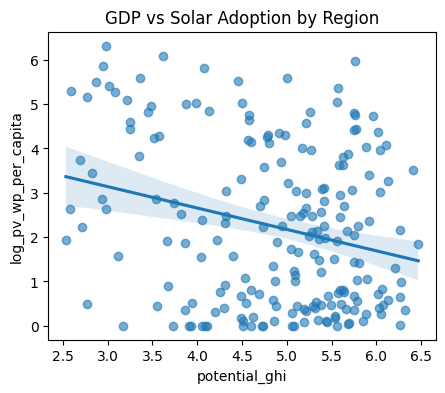

In [103]:
plt.figure(figsize=(5,4))
sns.regplot(
    data=df_world,
    x='potential_ghi',
    y='log_pv_wp_per_capita',
    scatter_kws={'alpha':0.6}
)

plt.title("GDP vs Solar Adoption by Region")
plt.show()

###Comparing countries with high sunlight but low adoption

In [104]:
high_resource_low_adoption = df_world[
    (df_world["potential_pvout"] > df_world["potential_pvout"].quantile(0.75)) &
    (df_world["pv_wp_per_capita"] < df_world["pv_wp_per_capita"].quantile(0.25))
][["country", "region", "potential_pvout", "potential_ghi", "gdp_per_capita", "potential_lcoe", "grid_reliability", "pv_wp_per_capita"]]

print(high_resource_low_adoption.sort_values("potential_pvout", ascending=False).head(20))

                  country region  potential_pvout  potential_ghi  \
108               Lesotho    AFR           5.1349         5.5414   
1             Afghanistan    SOA           5.0159         5.4904   
160                 Sudan    AFR           4.9432         6.3227   
57                Eritrea    AFR           4.8948         6.0715   
178  Syrian Arab Republic   MENA           4.8542         5.4529   
180                  Chad    AFR           4.8374         6.2617   
207                Zambia    AFR           4.8281         5.8834   
50               Djibouti   MENA           4.7972         6.0575   
167               Somalia    AFR           4.7617         6.0283   
60               Ethiopia    AFR           4.6954         5.8501   

     gdp_per_capita  potential_lcoe  grid_reliability  pv_wp_per_capita  
108     1324.282768          0.0836               0.0          0.189741  
1        520.896603          0.0851               0.0          0.591837  
160      977.273636          

Regional Comaprison

In [105]:
regional_summary = df_world.groupby("region").agg({
    "pv_wp_per_capita": "median",
    "gdp_per_capita": "median",
    "potential_ghi": "median",
    "potential_pvout": "median",
    "potential_lcoe": "median",
    "grid_reliability": "median",
    "rural_electricity_access": "median"
}).sort_values("pv_wp_per_capita", ascending=False)

print(regional_summary.sort_values("potential_pvout", ascending=False))

        pv_wp_per_capita  gdp_per_capita  potential_ghi  potential_pvout  \
region                                                                     
MENA            4.072561     6556.533341        5.89880          4.91670   
AFR             0.621794     1050.675254        5.62680          4.46410   
LCR            11.379844     7377.678832        5.26435          4.38565   
SOA             4.619782     1856.926644        5.18740          4.26690   
Other          92.764021    42029.762737        4.47125          3.97950   
EAP             9.988994     3998.646785        4.65940          3.88525   
ECA             9.108769     9016.660795        3.70035          3.60015   

        potential_lcoe  grid_reliability  rural_electricity_access  
region                                                              
MENA           0.08670               5.0                100.000000  
AFR            0.09535               0.0                 17.864900  
LCR            0.09775               5.

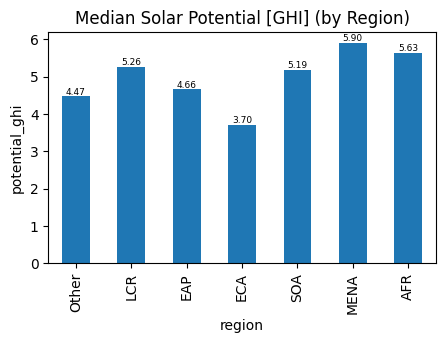

In [106]:
ax = regional_summary["potential_ghi"].plot(kind="bar", figsize=(5, 3))
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=6.5)

plt.ylabel("potential_ghi")
plt.title("Median Solar Potential [GHI] (by Region)")
plt.show()

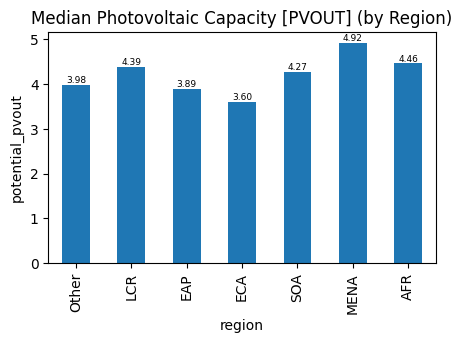

In [107]:
ax = regional_summary["potential_pvout"].plot(kind="bar", figsize=(5, 3))

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=6.5)

plt.ylabel("potential_pvout")
plt.title("Median Photovoltaic Capacity [PVOUT] (by Region)")
plt.show()

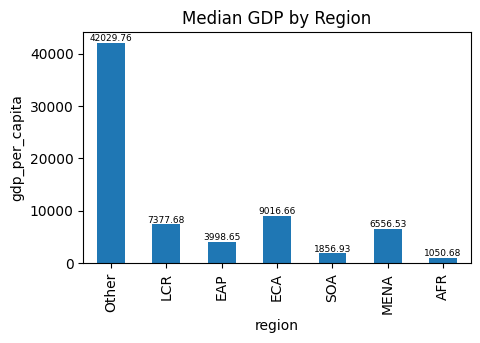

In [108]:
ax = regional_summary["gdp_per_capita"].plot(kind="bar", figsize=(5, 3))

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=6.5)

plt.ylabel("gdp_per_capita")
plt.title("Median GDP by Region")
plt.grid(False)
plt.show()

In [109]:
#regional_summary_clean = regional_summary.drop("Other")

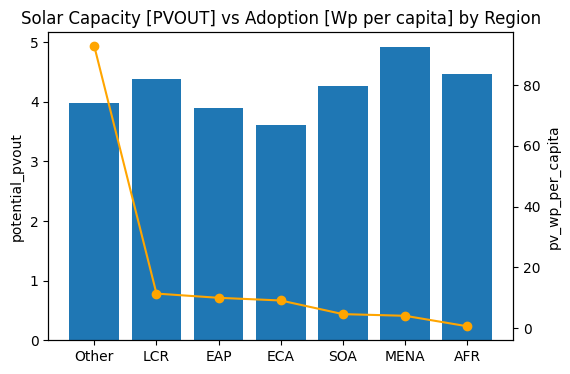

In [127]:
fig, ax1 = plt.subplots(figsize=(6,4))

# Bars (Potential)
ax1.bar(
    regional_summary.index,
    regional_summary["potential_pvout"]
)
ax1.set_ylabel("potential_pvout")

# Line (Adoption)
ax2 = ax1.twinx()
ax2.plot(
    regional_summary.index,
    regional_summary["pv_wp_per_capita"],
    marker="o",
    linewidth=1.5,
    color="orange"
)
ax2.set_ylabel("pv_wp_per_capita")

plt.title("Solar Capacity [PVOUT] vs Adoption [Wp per capita] by Region")
plt.xticks(rotation=45)
plt.show()

###regression models

In [111]:
import statsmodels.api as sm

X = df_world[[
    'gdp_per_capita',
    'grid_reliability',
    'potential_ghi',
    'potential_lcoe'
]]

X = sm.add_constant(X)  # adds intercept

y = df_world['log_pv_wp_per_capita']

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     log_pv_wp_per_capita   R-squared:                       0.413
Model:                              OLS   Adj. R-squared:                  0.399
Method:                   Least Squares   F-statistic:                     30.41
Date:                  Sun, 29 Mar 2026   Prob (F-statistic):           3.66e-19
Time:                          23:30:57   Log-Likelihood:                -305.36
No. Observations:                   178   AIC:                             620.7
Df Residuals:                       173   BIC:                             636.6
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               

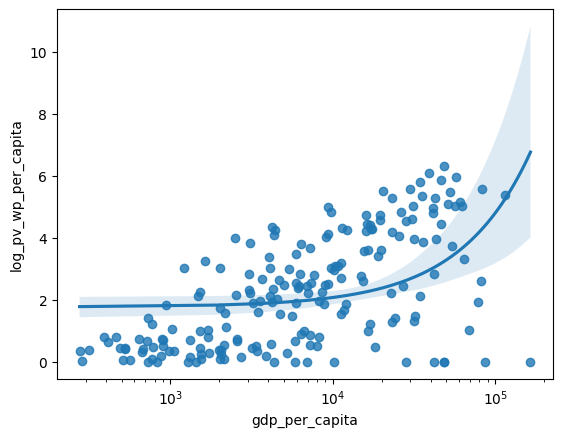

In [112]:
sns.regplot(
    data=df_world,
    x="gdp_per_capita",
    y="log_pv_wp_per_capita"
)
plt.xscale("log")

In [113]:
#for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df_world[[
    'gdp_per_capita',
    'hdi',
    'grid_reliability',
    'potential_ghi',
    'potential_lcoe'
]]

# Clean data
X = X.replace([np.inf, -np.inf], np.nan).dropna()

# Add constant
import statsmodels.api as sm
X = sm.add_constant(X)

# Calculate VIF
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

            feature         VIF
0             const  308.417576
1    gdp_per_capita    2.077537
2               hdi    3.703065
3  grid_reliability    2.488081
4     potential_ghi    2.705974
5    potential_lcoe    1.956091


In [114]:
model_features = [
    "gdp_per_capita",
    "potential_pvout",
    "seasonality",
    "rural_electricity_access",
    "power_consumption_per_capita",
    "grid_reliability"
]

model_features = [c for c in model_features if c in df_world.columns]

reg_df = df_world[["log_pv_wp_per_capita"] + model_features].dropna().copy()

X = reg_df[model_features]
y = reg_df["log_pv_wp_per_capita"]

reg_df_std = reg_df.copy()

scaler = StandardScaler()
reg_df_std[model_features] = scaler.fit_transform(reg_df_std[model_features])

X_std = sm.add_constant(reg_df_std[model_features])
y_std = reg_df_std["log_pv_wp_per_capita"]

std_model = sm.OLS(y_std, X_std).fit()
print(std_model.summary())

                             OLS Regression Results                             
Dep. Variable:     log_pv_wp_per_capita   R-squared:                       0.498
Model:                              OLS   Adj. R-squared:                  0.473
Method:                   Least Squares   F-statistic:                     19.66
Date:                  Sun, 29 Mar 2026   Prob (F-statistic):           7.56e-16
Time:                          23:31:14   Log-Likelihood:                -210.07
No. Observations:                   126   AIC:                             434.1
Df Residuals:                       119   BIC:                             454.0
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

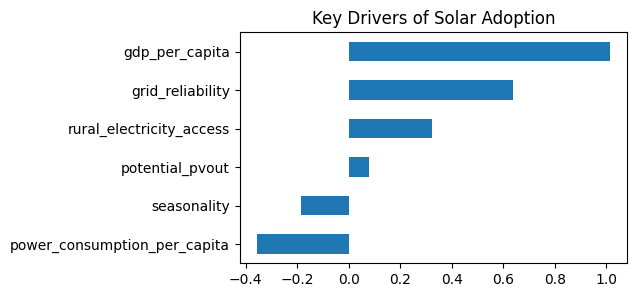

In [115]:
coef = std_model.params.drop("const")

plt.subplots(figsize=(5,3))

coef.sort_values().plot(kind="barh")
plt.title("Key Drivers of Solar Adoption")
plt.show()

###Clustering

In [116]:
cluster_features = [
    "potential_pvout",
    "potential_lcoe",
    "gdp_per_capita",
    "grid_reliability",
    "rural_electricity_access",
    "log_pv_wp_per_capita"
]

cluster_features = [c for c in cluster_features if c in df_world.columns]

cluster_df = df_world[["country", "region"] + cluster_features].copy()

imputer = SimpleImputer(strategy="median")
X_cluster = imputer.fit_transform(cluster_df[cluster_features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

print(cluster_df.groupby("cluster")[cluster_features].median())

         potential_pvout  potential_lcoe  gdp_per_capita  grid_reliability  \
cluster                                                                      
0                 4.3406          0.0982     1445.450809               0.0   
1                 3.3750          0.1206    31495.246776               7.1   
2                 4.4872          0.0931     9170.718591               6.0   

         rural_electricity_access  log_pv_wp_per_capita  
cluster                                                  
0                       36.978666              0.472096  
1                      100.000000              3.376596  
2                      100.000000              2.753228  


In [117]:
for c in sorted(cluster_df["cluster"].unique()):
    print(f"\nCluster {c}")
    print(cluster_df[cluster_df["cluster"] == c][["country", "region"]].head(15))


Cluster 0
                         country region
1                    Afghanistan    SOA
2                         Angola    AFR
13                       Burundi    AFR
15                         Benin    AFR
16                  Burkina Faso    AFR
17                    Bangladesh    SOA
30                      Botswana    AFR
31      Central African Republic    AFR
36                 Côte d'Ivoire    AFR
37                      Cameroon    AFR
38  Democratic Republic of Congo    AFR
39                         Congo    AFR
41                       Comoros    AFR
50                      Djibouti   MENA
57                       Eritrea    AFR

Cluster 1
                   country region
11                 Austria  Other
14                 Belgium  Other
18                Bulgaria    ECA
21  Bosnia and Herzegovina    ECA
22                 Belarus    ECA
28       Brunei Darussalam  Other
32                  Canada  Other
33             Switzerland  Other
48          Czech Republic    EC

In [118]:
cluster_labels = {
    1: "Developed Leaders",
    0: "Underperformers",
    2: "Emerging Markets",
}

cluster_df["cluster_name"] = cluster_df["cluster"].map(cluster_labels)

Text(0.5, 1.0, 'Solar Potential [PVOUT] by Economic contraints')

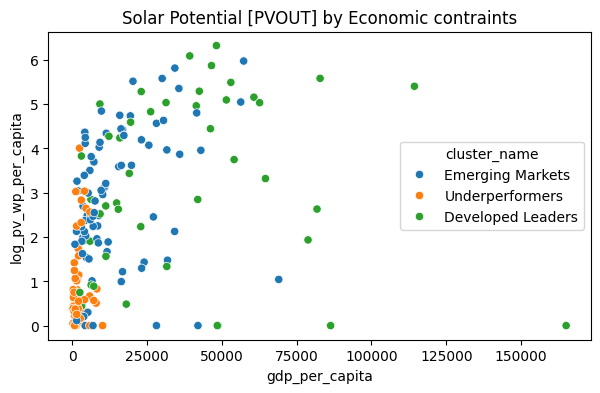

In [119]:
fig, ax1 = plt.subplots(figsize=(7,4))

sns.scatterplot(
    data=cluster_df,
    x="gdp_per_capita",
    y="log_pv_wp_per_capita",
    hue="cluster_name"
)
plt.title("Solar Potential [PVOUT] by Economic contraints")

###solar underperformance measure - solar potential / photovoltaic output Wp per capita

In [120]:
df_world["solar_underperformance"] = df_world["potential_pvout"] / (df_world["log_pv_wp_per_capita"] + 1)

underperf_cols = ["region", "potential_pvout", "log_pv_wp_per_capita", "gdp_per_capita", "solar_underperformance"]
print(df_world[underperf_cols].sort_values("solar_underperformance", ascending=False).head(5))

    region  potential_pvout  log_pv_wp_per_capita  gdp_per_capita  \
180    AFR           4.8374              0.012839      730.244608   
125  Other           4.6546              0.000000    28163.784873   
178   MENA           4.8542              0.079559             NaN   
108    AFR           5.1349              0.173736     1324.282768   
184    ECA           4.3678              0.000000     6966.635411   

     solar_underperformance  
180                4.776080  
125                4.654600  
178                4.496466  
108                4.374834  
184                4.367800  


In [121]:
top10 = (
    df_world[["country", "region", "potential_pvout", "log_pv_wp_per_capita", "gdp_per_capita", "solar_underperformance"]]
    .sort_values("solar_underperformance", ascending=False)
    .head(10)
)

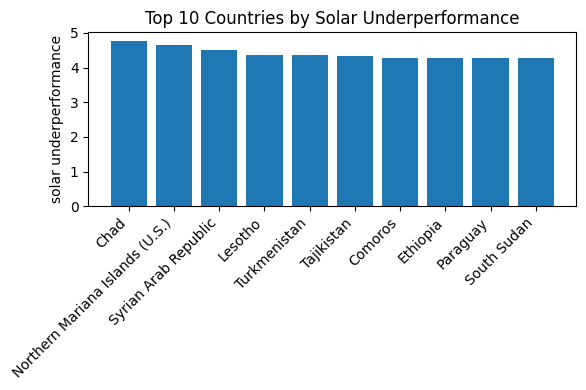

In [122]:
plt.figure(figsize=(6, 4))
plt.bar(top10["country"], top10["solar_underperformance"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("solar underperformance")
plt.title("Top 10 Countries by Solar Underperformance")
plt.tight_layout()
plt.show()

In [123]:
region_df = (
    df_world
    .groupby("region", as_index=False)
    .agg({
        "potential_pvout": "mean",
        "log_pv_wp_per_capita": "mean",
        "gdp_per_capita": "mean"
    })
)
region_df["solar_underperformance"] = region_df["potential_pvout"] / (region_df["log_pv_wp_per_capita"] + 1)

region_df = region_df.sort_values("solar_underperformance", ascending=False)

print(region_df)

  region  potential_pvout  log_pv_wp_per_capita  gdp_per_capita  \
0    AFR         4.457173              0.865925     2459.985914   
4   MENA         4.954695              1.879849    15989.132898   
6    SOA         4.312062              1.636151     3052.478261   
3    LCR         4.427734              2.475986     9687.800581   
1    EAP         3.950908              2.273062    11238.865593   
2    ECA         3.630057              2.352659    10820.165151   
5  Other         3.885567              3.796930    48240.407752   

   solar_underperformance  
0                2.388721  
4                1.720470  
6                1.635742  
3                1.273807  
1                1.207099  
2                1.082739  
5                0.810011  


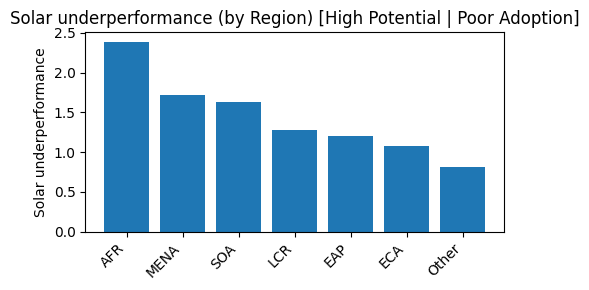

In [124]:
plt.figure(figsize=(5, 3))
plt.bar(region_df["region"], region_df["solar_underperformance"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Solar underperformance")
plt.title("Solar underperformance (by Region) [High Potential | Poor Adoption]")
plt.tight_layout()
plt.show()

In [125]:
# Countries with high resource but low adoption:
policy_targets = df_world[
    (df_world["potential_pvout"] > df_world["potential_pvout"].median()) &
    (df_world["log_pv_wp_per_capita"] < df_world["log_pv_wp_per_capita"].median())
][["country", "region", "potential_pvout", "potential_lcoe", "gdp_per_capita", "grid_reliability", "log_pv_wp_per_capita"]]

print(policy_targets.head(20))

                     country region  potential_pvout  potential_lcoe  \
1                Afghanistan    SOA           5.0159          0.0851   
2                     Angola    AFR           4.6586          0.0919   
6                  Argentina    LCR           4.5992          0.1084   
16              Burkina Faso    AFR           4.5701          0.0930   
19                   Bahrain   MENA           4.8686          0.0869   
20               The Bahamas    LCR           4.5481          0.0936   
25                   Bolivia    LCR           4.9421          0.0884   
30                  Botswana    AFR           5.1069          0.0833   
31  Central African Republic    AFR           4.4666          0.0952   
41                   Comoros    AFR           4.2856          0.1001   
50                  Djibouti   MENA           4.7972          0.0886   
57                   Eritrea    AFR           4.8948          0.0870   
60                  Ethiopia    AFR           4.6954          0.

In [126]:
country_by_region = (
    df_world
    .groupby("region")["country"]
    .apply(list)
    .reset_index()
)

print(country_by_region)

  region                                            country
0    AFR  [Angola, Burundi, Benin, Burkina Faso, Botswan...
1    EAP  [China, Fiji, Federated States of Micronesia, ...
2    ECA  [Albania, Armenia, Azerbaijan, Bulgaria, Bosni...
3    LCR  [Argentina, Antigua and Barbuda, The Bahamas, ...
4   MENA  [United Arab Emirates, Bahrain, Djibouti, Alge...
5  Other  [Aruba (Neth.), Andorra, American Samoa (U.S.)...
6    SOA  [Afghanistan, Bangladesh, Bhutan, India, Sri L...


In [ ]:
country_region_table = df_world[df_world["region"] == "Other"][["country", "region"]]

print(country_region_table)

                                 country region
0                          Aruba (Neth.)  Other
4                                Andorra  Other
8                  American Samoa (U.S.)  Other
10                             Australia  Other
11                               Austria  Other
14                               Belgium  Other
24                        Bermuda (U.K.)  Other
28                     Brunei Darussalam  Other
32                                Canada  Other
33                           Switzerland  Other
44                                  Cuba  Other
45                       Curaçao (Neth.)  Other
46                 Cayman Islands (U.K.)  Other
49                               Germany  Other
52                               Denmark  Other
58                                 Spain  Other
62                                France  Other
65                        United Kingdom  Other
72                                Greece  Other
75                           Guam (U.S.)

####End